In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 9.0
https://www.nv5geospatialsoftware.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [2]:
'''
Create vegetation land mask
'''

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]

cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
vege_ds = vege_ds.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")

full_lai = vege_ds.lai_hv + vege_ds.lai_lv
full_lai_max = full_lai.max('time')

vege_mask = full_lai_max.where(full_lai_max>3.5)


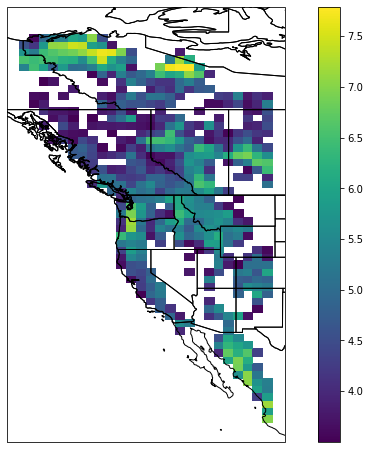

In [3]:
fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

vege_mask.plot(ax=axs,transform=ccrs.PlateCarree())
axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)

plt.show()
plt.close(fig)

In [3]:
'''
Create vegetation land mask
'''

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]

d4pdf_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')

vege_ds = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
vege_ds = vege_ds.interp(longitude=d4pdf_da.longitude, latitude=d4pdf_da.latitude, method="linear")

full_lai = vege_ds.lai_hv + vege_ds.lai_lv
full_lai_max = full_lai.max('time')

d4pdf_vege_mask = full_lai_max.where(full_lai_max>3.5)


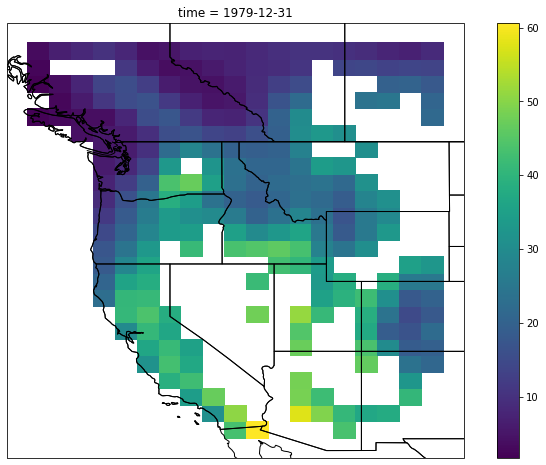

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


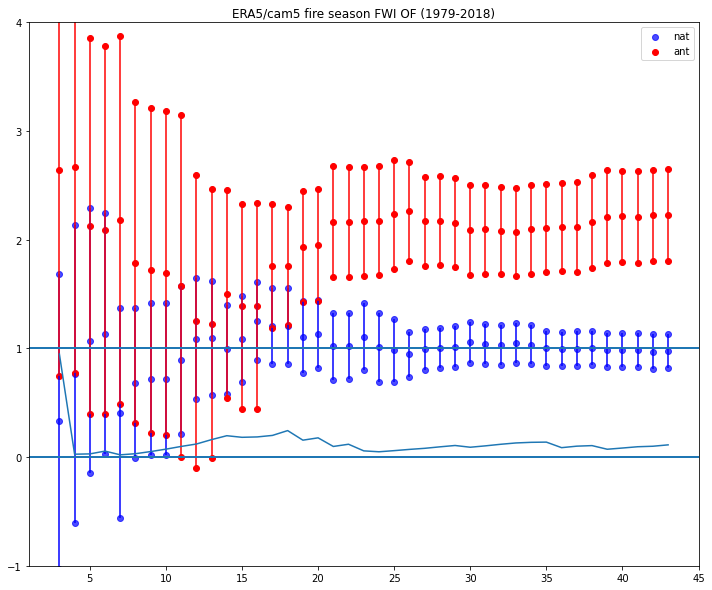

In [7]:
'''
MAIN function for performing optimal fingerprinting using cam5 and ERA5
'''

boxes = [[(32,55),(232,256)]]#,['full',(32,55),(232,250)],[(32,55),(235,245)]]

for vege_mask_flag in [True]:
    for box in boxes:
        #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')
        da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        if box != 'full':
            da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        if vege_mask_flag:
            da = da.where(vege_mask>0)
        da = da.sel(time=slice("1979","2018"))
        
        fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

        da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
        axs.coastlines()  # cartopy function
        axs.add_feature(cf.BORDERS)
        axs.add_feature(cf.STATES)

        plt.show()
        plt.close(fig)


        IDL.retall

        print('getting ALL mean and noise')
        all_ens_mean,noise_all = get_mean_and_noise('All', box, vege_mask_flag)
        #print('getting ANT mean and noise')
        #ant_ens_mean,noise_ant = get_mean_and_noise('Ant', box, vege_mask_flag)
        print('getting NAT mean and noise')
        nat_ens_mean,noise_nat = get_mean_and_noise('Nat', box, vege_mask_flag)

        print('getting obs')
        data_obs = get_obs_data(box, vege_mask_flag)
        print('got obs')
        data_scen = np.array([all_ens_mean,nat_ens_mean])
        #data_scen = np.array([ant_ens_mean,nat_ens_mean])

        data_noise_1 = np.concatenate((noise_all[:22],noise_nat[:24]))
        data_noise_2 = np.concatenate((noise_all[22:],noise_nat[24:]))

        print('got arrays')

        trunc = np.array([i for i in range(3,44)])

        IDL.data_obs = data_obs
        IDL.data_scen = data_scen
        IDL.data_noise_1 = data_noise_1
        IDL.data_noise_2 = data_noise_2
        IDL.trunc = trunc
        IDL.scan_beta_est = []
        IDL.scan_p_resid = []

        print('running gendetec')
        IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
                data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
                scan_p_resid=scan_p_resid")

        #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
        #        data_noise_2=data_noise_2, trunc=trunc, scan_beta_est=scan_beta_est")

        scan_beta_est = IDL.scan_beta_est
        scan_p_resid = IDL.scan_p_resid

        plot_result(scan_beta_est,scan_p_resid)

        da.close()
    

In [10]:
scan_p_resid

array([0.38786814, 0.03802445, 0.07357986, 0.12171772, 0.14978161,
       0.1869931 , 0.26179716, 0.34483582, 0.36234617, 0.43048623,
       0.40578827, 0.4673468 , 0.5105127 , 0.5670711 , 0.6308377 ,
       0.6899772 , 0.73169893, 0.7787891 , 0.78182083, 0.80631036,
       0.49539524, 0.48177627, 0.28469163, 0.32363558, 0.28930965,
       0.23165384, 0.22770815, 0.25470406, 0.2815026 , 0.19858412,
       0.22282872, 0.25021112, 0.24584448, 0.27418593, 0.2752633 ,
       0.19905894, 0.1311015 , 0.13787018, 0.11365622, 0.12845917,
       0.14281607], dtype=float32)

In [3]:
def get_obs_data(box, vege_mask_flag):
    
    #cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_All_ensMean.nc')
    cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
    
    #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')
    da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    
    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        da = da.where(vege_mask>0)
        
    da = da.sel(time=slice("1979","2018"))
    da = da.where(~cam5.isnull())
    
    da = da.stack(pixel=("latitude", "longitude"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)


In [4]:
def get_noise(era5_da,scen,ens_mean,box,vege_mask_flag):
    runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
            'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)],
            'Ant':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}

    
    noise = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        #mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_'+scen+'_run'+number+'.nc')
        mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice("1979","2018"))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [5]:
def get_mean_and_noise(scen, box, vege_mask_flag):
    
    #era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')

    #ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_'+scen+'_ensMean.nc')
    ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice("1979","2018"))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(era5_da,scen,ens_mean,box,vege_mask_flag)

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()

    del ens_mean
    
    return((ens_mean_array, np.array(noise)))


In [6]:
def plot_result(scan_beta_est,scan_p_resid):

    fig,axs = plt.subplots(figsize=(12,10))

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        axs.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        axs.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

        axs.vlines(j+3,low_2,up_2,colors=['blue'])
        axs.vlines(j+3,low_1,up_1,colors=['red'])

        axs.axhline(0,-0.5,1.5)
        axs.axhline(1,-0.5,1.5)
        
    axs.plot([i+3 for i in range(len(scan_p_resid))],scan_p_resid)

    axs.legend()
    axs.set_ylim(-1,4)

    plt.title('ERA5/cam5 fire season FWI OF (1979-2018)')
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    plt.show()
    #plt.close(fig)
    

In [50]:
cam5_all = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
cam5_nat = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')
cam5_ant = cam5_all - cam5_nat

d4pdf_all = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
d4pdf_nat = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')
d4pdf_ant = d4pdf_all - d4pdf_nat

In [5]:
cam5_all_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_All_ensMean.nc')
cam5_nat_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_Nat_ensMean.nc')
cam5_ant_95 = cam5_all_95 - cam5_nat_95

d4pdf_all_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_HPB_ensMean.nc')
d4pdf_nat_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_HPB_NAT_ensMean.nc')
d4pdf_ant_95 = d4pdf_all_95 - d4pdf_nat_95

In [4]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


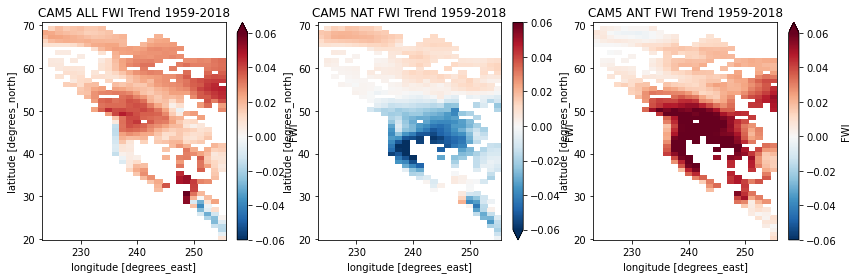

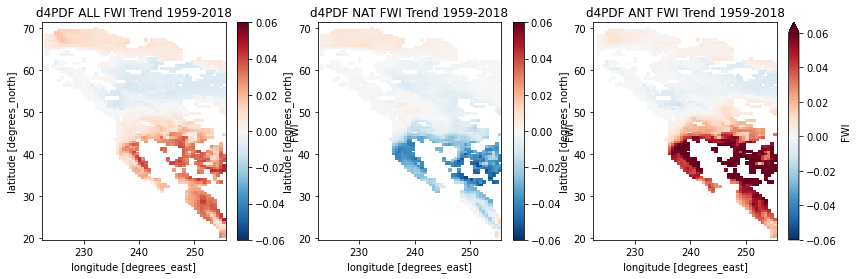

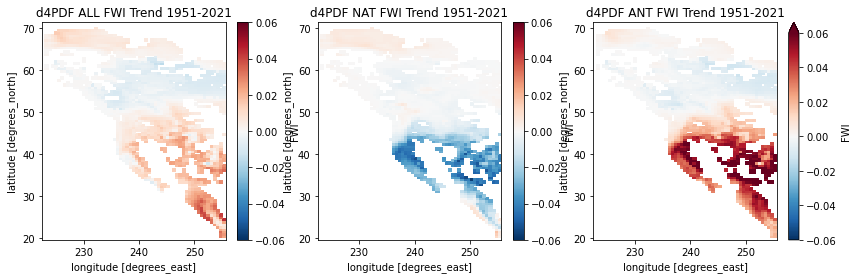

In [60]:
fig,axs = plt.subplots(1,3,figsize=(14,4))
axs = axs.flatten()
names = ['ALL','NAT','ANT']
for i,da in enumerate([cam5_all,cam5_nat,cam5_ant]):
    da = da.sel(time=slice('1959','2018'))
    da = da.where(vege_mask>0)
    xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],vmin=-0.06,vmax=0.06,cmap='RdBu_r')
    axs[i].set_title("CAM5 " + names[i] + " FWI Trend 1959-2018")   
plt.show()
plt.close(fig)

fig,axs = plt.subplots(1,3,figsize=(14,4))
axs = axs.flatten()
names = ['ALL','NAT','ANT']
for i,da in enumerate([d4pdf_all,d4pdf_nat,d4pdf_ant]):
    da = da.sel(time=slice('1959','2018'))
    da = da.where(d4pdf_vege_mask>0)
    xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],vmin=-0.06,vmax=0.06,cmap='RdBu_r')
    axs[i].set_title("d4PDF " + names[i] + " FWI Trend 1959-2018")
plt.show()
plt.close(fig)

fig,axs = plt.subplots(1,3,figsize=(14,4))
axs = axs.flatten()
names = ['ALL','NAT','ANT']
for i,da in enumerate([d4pdf_all,d4pdf_nat,d4pdf_ant]):
    da = da.where(d4pdf_vege_mask>0)
    xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],vmin=-0.06,vmax=0.06,cmap='RdBu_r')
    axs[i].set_title("d4PDF " + names[i] + " FWI Trend 1951-2021")

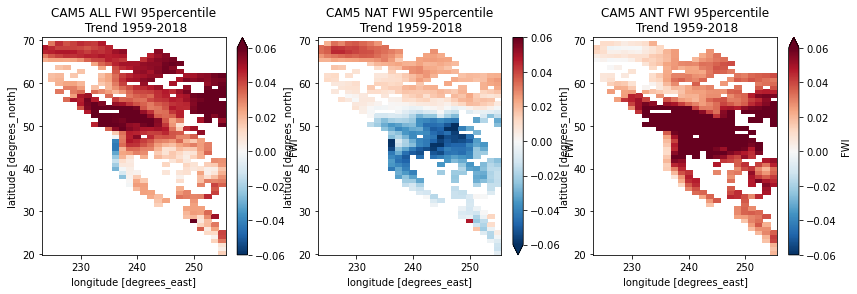

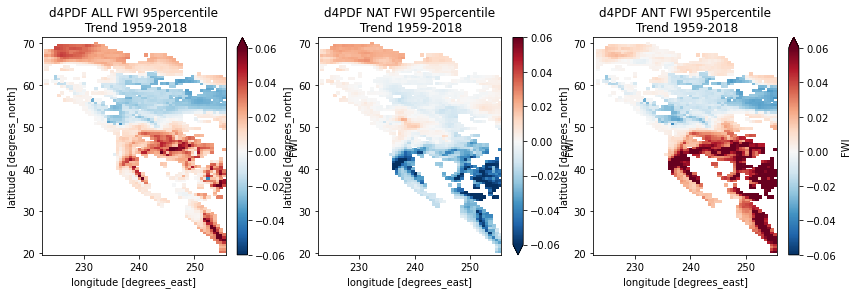

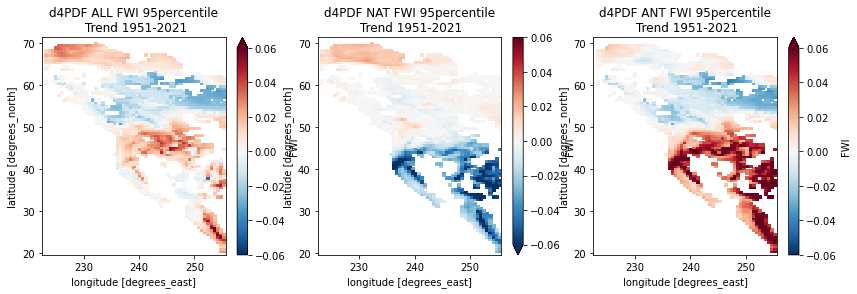

In [9]:
fig,axs = plt.subplots(1,3,figsize=(14,4))
axs = axs.flatten()
names = ['ALL','NAT','ANT']
for i,da in enumerate([cam5_all_95,cam5_nat_95,cam5_ant_95]):
    da = da.sel(time=slice('1959','2018'))
    da = da.where(vege_mask>0)
    xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],vmin=-0.06,vmax=0.06,cmap='RdBu_r')
    axs[i].set_title("CAM5 " + names[i] + " FWI 95percentile\n Trend 1959-2018")
    
plt.show()
plt.close(fig)

fig,axs = plt.subplots(1,3,figsize=(14,4))
axs = axs.flatten()
names = ['ALL','NAT','ANT']
for i,da in enumerate([d4pdf_all_95,d4pdf_nat_95,d4pdf_ant_95]):
    da = da.sel(time=slice('1959','2018'))
    da = da.where(d4pdf_vege_mask>0)
    xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],vmin=-0.06,vmax=0.06,cmap='RdBu_r')
    axs[i].set_title("d4PDF " + names[i] + " FWI 95percentile\n Trend 1959-2018")
plt.show()
plt.close(fig)

fig,axs = plt.subplots(1,3,figsize=(14,4))
axs = axs.flatten()
names = ['ALL','NAT','ANT']
for i,da in enumerate([d4pdf_all_95,d4pdf_nat_95,d4pdf_ant_95]):
    da = da.where(d4pdf_vege_mask>0)
    xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],vmin=-0.06,vmax=0.06,cmap='RdBu_r')
    axs[i].set_title("d4PDF " + names[i] + " FWI 95percentile\n Trend 1951-2021")
    

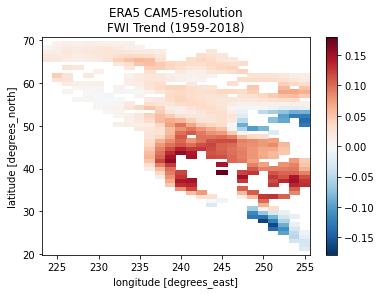

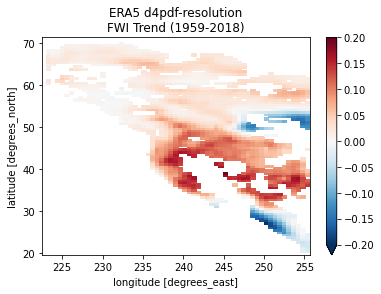

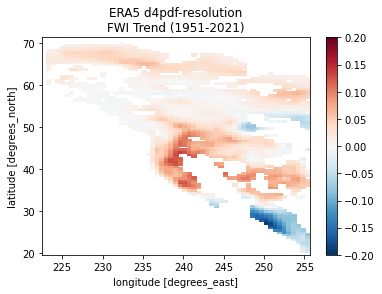

In [11]:
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
da = da.where(vege_mask>0)
da = da.sel(time=slice('1959','2018'))
xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot()#vmin=-0.06,vmax=0.06,cmap='RdBu_r')
plt.title('ERA5 CAM5-resolution\nFWI Trend (1959-2018)')
plt.show()
plt.close(fig)

da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
da = da.where(d4pdf_vege_mask>0)
da = da.sel(time=slice('1959','2018'))
xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(vmin=-0.2,vmax=0.2,cmap='RdBu_r')
plt.title('ERA5 d4pdf-resolution\nFWI Trend (1959-2018)')
plt.show()
plt.close(fig)

da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
da = da.where(d4pdf_vege_mask>0)
da = da.sel(time=slice('1951','2021'))
xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(vmin=-0.2,vmax=0.2,cmap='RdBu_r')
plt.title('ERA5 d4pdf-resolution\nFWI Trend (1951-2021)')
plt.show()
plt.close(fig)

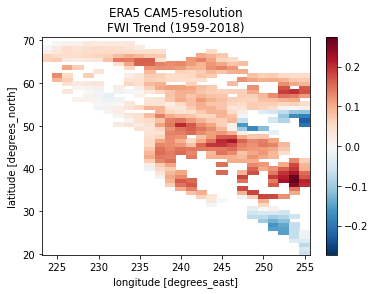

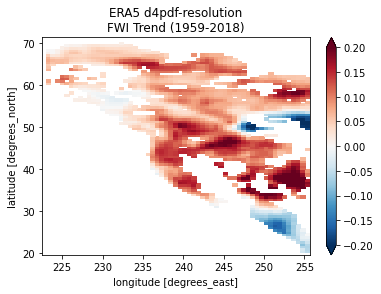

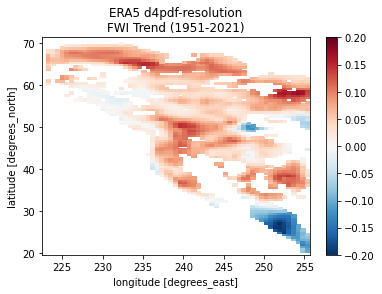

In [13]:
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')
da = da.where(vege_mask>0)
da = da.sel(time=slice('1959','2018'))
xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot()#vmin=-0.06,vmax=0.06,cmap='RdBu_r')
plt.title('ERA5 CAM5-resolution\nFWI Trend (1959-2018)')
plt.show()
plt.close(fig)

da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
da = da.where(d4pdf_vege_mask>0)
da = da.sel(time=slice('1959','2018'))
xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(vmin=-0.2,vmax=0.2,cmap='RdBu_r')
plt.title('ERA5 d4pdf-resolution\nFWI Trend (1959-2018)')
plt.show()
plt.close(fig)

da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
da = da.where(d4pdf_vege_mask>0)
da = da.sel(time=slice('1951','2021'))
xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(vmin=-0.2,vmax=0.2,cmap='RdBu_r')
plt.title('ERA5 d4pdf-resolution\nFWI Trend (1951-2021)')
plt.show()
plt.close(fig)

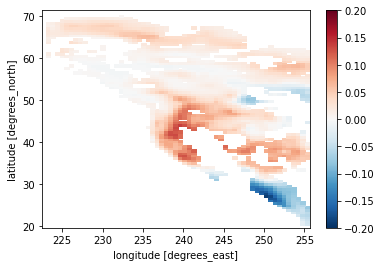